In [51]:
#Imports et lecture des données
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

np.random.seed(42)


In [2]:
# Récupération des fichiers *2021.csv
files_2021 = sorted(Path("../data/cleaned").rglob("*_2021.csv"))

print("Nb de fichiers 2021 trouvés:", len(files_2021))
for p in files_2021:
    print("-", p.as_posix())

assert len(files_2021) > 0, "Aucun CSV 2021 trouvé !"


Nb de fichiers 2021 trouvés: 8
- ../data/cleaned/cleaned2021/cleaned_75_2021.csv
- ../data/cleaned/cleaned2021/cleaned_77_2021.csv
- ../data/cleaned/cleaned2021/cleaned_78_2021.csv
- ../data/cleaned/cleaned2021/cleaned_91_2021.csv
- ../data/cleaned/cleaned2021/cleaned_92_2021.csv
- ../data/cleaned/cleaned2021/cleaned_93_2021.csv
- ../data/cleaned/cleaned2021/cleaned_94_2021.csv
- ../data/cleaned/cleaned2021/cleaned_95_2021.csv


In [3]:
# Chargement des données
df = pd.concat([pd.read_csv(p) for p in files_2021], ignore_index=True)


In [4]:
df.shape

(93007, 8)

In [5]:
df.head()


,property_value,postal_code,department_code,town_code,property_type_code,building_area,main_rooms,land_area
0,"63600000,00",75008.0,75,108,4.0,1878.0,0.0,476.0
1,"194500,00",75008.0,75,108,4.0,844.0,0.0,623.0
2,"194500,00",75008.0,75,108,4.0,346.0,0.0,584.0
3,"194500,00",75008.0,75,108,4.0,6100.0,0.0,584.0
4,"143500000,00",75008.0,75,108,4.0,810.0,0.0,1282.0


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93007 entries, 0 to 93006
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   property_value      93007 non-null  object 
 1   postal_code         93007 non-null  float64
 2   department_code     93007 non-null  int64  
 3   town_code           93007 non-null  int64  
 4   property_type_code  93007 non-null  float64
 5   building_area       93007 non-null  float64
 6   main_rooms          93007 non-null  float64
 7   land_area           93007 non-null  float64
dtypes: float64(5), int64(2), object(1)
memory usage: 5.7+ MB


In [7]:
df.describe()

,postal_code,department_code,town_code,property_type_code,building_area,main_rooms,land_area
count,93007.000000,93007.000000,93007.000000,93007.000000,93007.000000,93007.000000,93007.000000
mean,85930.447074,85.549023,249.959272,1.688454,141.843775,3.166074,813.709904
std,7929.216994,7.939137,200.724372,1.021576,981.324370,2.380546,3908.472434
min,75001.000000,75.000000,1.000000,1.000000,0.000000,0.000000,1.000000
25%,77650.000000,77.000000,66.000000,1.000000,38.000000,0.000000,246.000000
50%,91180.000000,91.000000,204.000000,1.000000,82.000000,4.000000,415.000000
75%,93340.000000,93.000000,412.000000,3.000000,120.000000,5.000000,600.000000
max,95880.000000,95.000000,692.000000,4.000000,137442.000000,70.000000,281755.000000


In [8]:
# Nettoyage de property_value
# La colonne property_value est actuellement de type object (chaîne de caractères)
# car les valeurs contiennent une virgule comme séparateur décimal (ex: "194500,00").
# Cela peut empêcher toute opération mathématique ou modélisation.
# On remplace donc les virgules par rien, puis on convertit en float pour rendre
# les valeurs exploitables par les algorithmes de Machine Learning.
df['property_value'] = (
    df['property_value']
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [9]:
df.head()

,property_value,postal_code,department_code,town_code,property_type_code,building_area,main_rooms,land_area
0,6.360000e+09,75008.0,75,108,4.0,1878.0,0.0,476.0
1,1.945000e+07,75008.0,75,108,4.0,844.0,0.0,623.0
2,1.945000e+07,75008.0,75,108,4.0,346.0,0.0,584.0
3,1.945000e+07,75008.0,75,108,4.0,6100.0,0.0,584.0
4,1.435000e+10,75008.0,75,108,4.0,810.0,0.0,1282.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93007 entries, 0 to 93006
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   property_value      93007 non-null  float64
 1   postal_code         93007 non-null  float64
 2   department_code     93007 non-null  int64  
 3   town_code           93007 non-null  int64  
 4   property_type_code  93007 non-null  float64
 5   building_area       93007 non-null  float64
 6   main_rooms          93007 non-null  float64
 7   land_area           93007 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 5.7 MB


In [11]:
# Je crée mes deux cibles principales :
# prix_total : valeur foncière totale
# prix_m2 : prix rapporté à la surface bâtie, plus adapté à la comparaison entre biens

df = df[df["building_area"] > 0].copy()
df["prix_total"] = df["property_value"].astype(float)
df["prix_m2"] = df["prix_total"] / df["building_area"]

In [12]:
# Je définis quelles variables serviront à prédire le prix
#Définition des variables explicatives
cat_cols = ["postal_code", "department_code", "town_code", "property_type_code"] #Variables catégorielles
num_cols = ["building_area", "main_rooms", "land_area"]      #Variables numériques
features = cat_cols + num_cols

In [13]:
# Préprocesseur adapté aux modèles linéaires
preproc_linear = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", StandardScaler(), num_cols),
    ]
)

In [14]:
# Préprocesseur adapté aux modèles d’arbres (Random Forest)
preproc_tree = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)


In [15]:
# Création d'un échantillon d'apprentissage et de test
X = df[features]    # matrice des caractérisques
y = df["prix_total"]  # prédiction du prix total des biens


In [16]:
#Séparation des données 20% pr la validation & 80% ds l'entrainement
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# Modèle baseline : RidgeCV
# Ce modèle linéaire sert de point de comparaison pour les modèles plus complexes

ridge = Pipeline([
    ("prep", preproc_linear),
    ("model", RidgeCV(alphas=np.logspace(-3, 3, 13)))
])
ridge.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
#Prédiction de notre cible sur le jeu de validation
pred_ridge = ridge.predict(X_val)

In [19]:
#Evaluation du modèle Rigde
ridge_mae = mean_absolute_error(y_val, pred_ridge)   #Erreur Moy Abs
ridge_rmse = np.sqrt(mean_squared_error(y_val, pred_ridge)) # Racine de l'erreur quadratique moy
ridge_r2 = r2_score(y_val, pred_ridge)   #Coef de dét.


In [20]:
print("Ridge → MAE:", ridge_mae, " RMSE:", ridge_rmse, " R²:", ridge_r2)

Ridge → MAE: 156237637.81678516  RMSE: 721568979.5280728  R²: 0.3154288000282177


In [21]:
# Modèle linéaire avec pénalisation L1 : LASSO
# Ce modèle peut éliminer certaines variables inutiles (sélection de features)

lasso = Pipeline([
    ("prep", preproc_linear),
    ("model", LassoCV(
        alphas=np.logspace(-3, 1, 9),  # teste de plusieurs valeurs de régularisation
        max_iter=5000,
        random_state=42
    ))
])

In [22]:
#Apprentissage sur les données train
lasso.fit(X_train, y_train)

#Prédiction
pred_lasso = lasso.predict(X_val)

/workspaces/gpd-m2sep-france-property-insight/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.318e+21, tolerance: 2.826e+18
  model = cd_fast.enet_coordinate_descent_gram(
/workspaces/gpd-m2sep-france-property-insight/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.893e+21, tolerance: 2.826e+18
  model = cd_fast.enet_coordinate_descent_gram(
/workspaces/gpd-m2sep-france-property-insight/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the n

In [23]:
#Evaluation du modèle Lasso
lasso_mae = mean_absolute_error(y_val, pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_val, pred_lasso)) 
lasso_r2 = r2_score(y_val, pred_lasso)

In [ ]:
print("Lasso → MAE:", round(lasso_mae, 2), 
      " RMSE:", round(lasso_rmse, 2), 
      " R²:", round(lasso_r2, 3)) 

Lasso → MAE: 156004384.85  RMSE: 721436788.89  R²: 0.316


In [25]:
# Modèle avancé : Random Forest Regressor
# Ce modèle non linéaire capture mieux la réalité du marché immobilier

rf = Pipeline([
    ("prep", preproc_tree),
    ("model", RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

In [26]:
# Apprentissage
rf.fit(X_train, y_train)
#Prédiction
pred_rf = rf.predict(X_val)

In [27]:
#Evaluation du modèle Random Forest
rf_mae = mean_absolute_error(y_val, pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_val, pred_rf))
rf_r2 = r2_score(y_val, pred_rf)

In [ ]:
print("Random Forest → MAE:", rf_mae, " RMSE:", rf_rmse, " R²:", rf_r2)

Random Forest → MAE: 37487979.49527496  RMSE: 295721618.4936852  R²: 0.8850182102817656


In [29]:
# Variable importance
importances = rf.named_steps["model"].feature_importances_
feature_names = (
    rf.named_steps["prep"]
    .named_transformers_["cat"]
    .get_feature_names_out(cat_cols)
    .tolist()
    + num_cols
)


In [30]:
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(15)

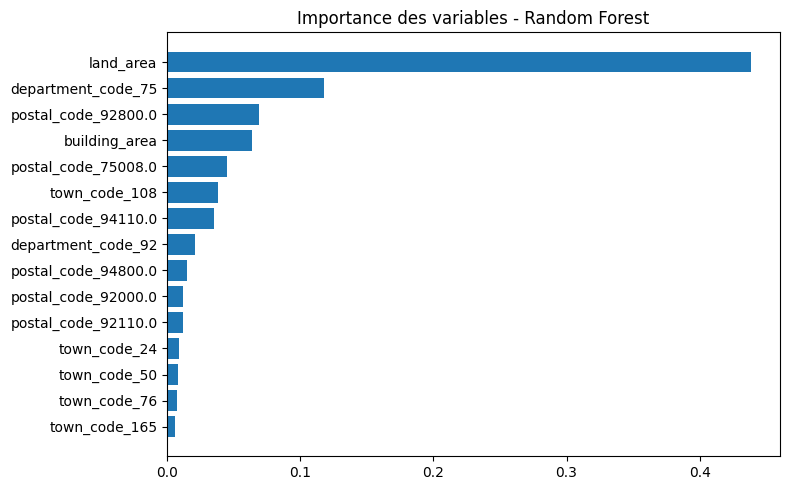

In [31]:
# Importance des variables
plt.figure(figsize=(8,5))
plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1])
plt.title("Importance des variables - Random Forest")
plt.tight_layout()
plt.show()

In [32]:
# Calcul des résidus
residuals = y_val - pred_rf  # Erreur = valeur réelle - prédiction


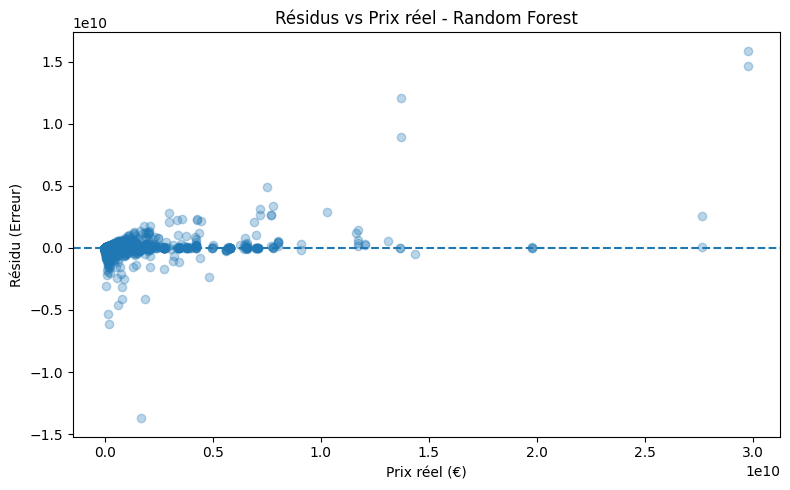

In [33]:
# Graphique des résidus vs prix réel
plt.figure(figsize=(8,5))
plt.scatter(y_val, residuals, alpha=0.3)
plt.axhline(0, linestyle='--')
plt.xlabel("Prix réel (€)")
plt.ylabel("Résidu (Erreur)")
plt.title("Résidus vs Prix réel - Random Forest")
plt.tight_layout()
plt.show()

In [34]:
# On observe que la majorité des biens sont correctement prédits, avec des erreurs modérées 
# et centrées autour de zéro. En revanche, quelques biens très chers génèrent des erreurs plus 
# importantes : le modèle a plus de difficulté à capturer la dynamique des biens les plus haut 
# de gamme, dont les prix dépendent souvent de caractéristiques très locales et qualitatives 
# (prestige du quartier, vue, finitions…).
#Donc le modèle généralise bien pour le marché courant, mais reste moins performant sur 
# les biens d’exception.

In [35]:
# Modèle Gradient Boosting
from sklearn.pipeline import Pipeline

gb = Pipeline([
    ("prep", preproc_tree),
    ("model", GradientBoostingRegressor(
        n_estimators=300,      # nombre d’arbres
        learning_rate=0.05,   # pas d’apprentissage
        max_depth=3,          # profondeur des arbres
        subsample=0.8,        # pour limiter l’overfitting
        random_state=42
    ))
])


In [36]:
# Entrainement
gb.fit(X_train, y_train)


,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [37]:
# Prédictions
pred_gb = gb.predict(X_val)

In [38]:
#Evaluation du modèle Gradient Boosting
gb_mae  = mean_absolute_error(y_val, pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_val, pred_gb))
gb_r2   = r2_score(y_val, pred_gb)

In [ ]:
# Résultats des métrics
print("Gradient Boosting -> MAE:", round(gb_mae, 2),
      "RMSE:", round(gb_rmse, 2),
      "R²:", round(gb_r2, 3))

Gradient Boosting -> MAE: 87967173.02 RMSE: 379079533.42 R²: 0.811


In [40]:
#Modèle DecisionTree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_val)

In [41]:
# Evaluation du modèle DecisionTree
mae = mean_absolute_error(y_val, y_pred_dt)
rmse =np.sqrt(mean_squared_error(y_val, y_pred_dt))
r2 = r2_score(y_val, y_pred_dt)

In [42]:
# Résultats des métrics DT
print(f"DecisionTree - MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")


DecisionTree - MAE: 37780844.61, RMSE: 380715662.52, R²: 0.809


In [ ]:
# Comparaison visuelle des modèles
results = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'RandomForest', 'GradientBoosting', 'DecisionTree'],
    'MAE': [ridge_mae, lasso_mae, rf_mae, gb_mae, mae],
    'RMSE': [ridge_rmse, lasso_rmse, rf_rmse, gb_rmse, rmse],
    'R2': [ridge_r2, lasso_r2, rf_r2, gb_r2, r2]
})


In [50]:
results.sort_values(by='R2', ascending=False)


,Model,MAE,RMSE,R2
2,RandomForest,3.748798e+07,2.957216e+08,0.885018
3,GradientBoosting,8.796717e+07,3.790795e+08,0.811060
4,DecisionTree,3.778084e+07,3.807157e+08,0.809426
1,Lasso,1.560044e+08,7.214368e+08,0.315680
0,Ridge,1.562376e+08,7.215690e+08,0.315429


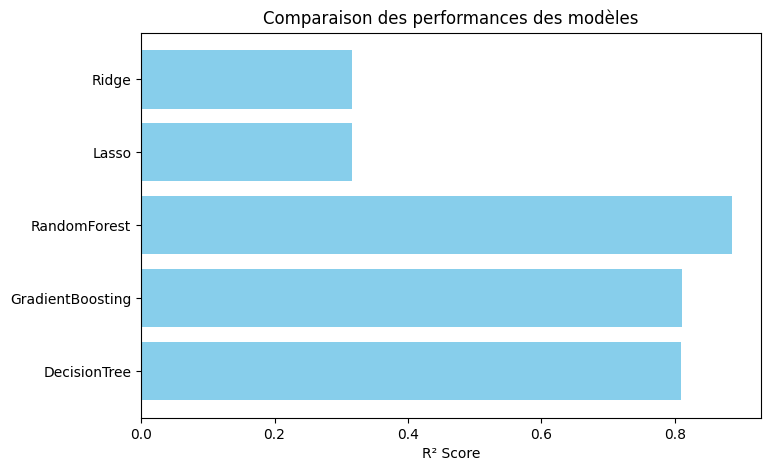

In [ ]:


plt.figure(figsize=(8, 5))
plt.barh(results['Model'], results['R2'], color='skyblue')
plt.xlabel("R² Score")
plt.title("Comparaison des performances des modèles")
plt.gca().invert_yaxis()
plt.show()


In [56]:
# recherche d’hyperparamètres pour les deux meilleurs modèles
# Random Forest optimisée avec RandomizedSearchCV

In [57]:
# Grille d’hyperparamètres
param_dist_rf = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

In [58]:
# Pipeline existant
rf_pipe = Pipeline([
    ("prep", preproc_tree),
    ("model", RandomForestRegressor(random_state=42))
])

In [59]:
# Randomized Search
rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist_rf,
    n_iter=15,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

In [60]:
rf_search.fit(X_train, y_train)
print("Meilleurs paramètres RF :", rf_search.best_params_)
print("Meilleur RMSE (validation):", -rf_search.best_score_)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time= 1.1min
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time= 1.2min
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time= 1.2min
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=300; total time= 1.9min
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=300; total time= 1.9min
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=300; total time= 1.7min
[CV] E

In [1]:
# Gradient Boosting optimisé avec GridSearchCV
param_grid_gb = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 4, 5],
    "model__min_samples_leaf": [1, 3, 5],
    "model__subsample": [0.8, 1.0]
}

In [2]:
gb_pipe = Pipeline([
    ("prep", preproc_tree),
    ("model", GradientBoostingRegressor(random_state=42))
])

NameError: name 'Pipeline' is not defined

In [ ]:
gb_search = GridSearchCV(
    gb_pipe,
    param_grid=param_grid_gb,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

In [ ]:
gb_search.fit(X_train, y_train)
print("Meilleurs paramètres GB :", gb_search.best_params_)
print("Meilleur RMSE (validation):", -gb_search.best_score_)


In [ ]:
Comparer les modèles optimisés
best_rf = rf_search.best_estimator_
best_gb = gb_search.best_estimator_

# Évaluation sur ton jeu de validation
for name, model in [("RandomForest", best_rf), ("GradientBoosting", best_gb)]:
    pred = model.predict(X_val)
    mae = mean_absolute_error(y_val, pred)
    rmse = mean_squared_error(y_val, pred, squared=False)
    r2 = r2_score(y_val, pred)
    print(f"{name} → MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.3f}")
